In [1]:
import torch
from matplotlib import pyplot as plt
import random
from flow_matching.supervised.odes_sdes import CFGVectorFieldODE
from flow_matching.supervised.alphas_betas import LinearAlpha, LinearBeta
from flow_matching.supervised.prob_paths import GaussianConditionalProbabilityPath
from flow_matching.whar.sampler import WHARSampler
from flow_matching.whar.models.latent_transformer import FlowTransformerBackbone
from flow_matching.whar.models.latent_cnn import FiLMNetMultiBlock
from flow_matching.latent.training_flow import LatentFlowTrainer
from flow_matching.supervised.simulators import RK4Simulator
from matplotlib import pyplot as plt
from flow_matching.latent.training_cae import detransform, transform
from flow_matching.whar.stft import plot_spectrogram_grid, decompress_stft

# from flow_matching.whar.models.autoencoder import (
#     SpectrogramCAE,
#     SpectrogramAEC,
#     SpectrogramAE,
# )

from flow_matching.whar.models.autoencoder_8 import (
    SpectrogramCAE,
    SpectrogramAEC,
    SpectrogramAE,
)

In [8]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    # elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

cpu


In [4]:
sampler = WHARSampler(subject_id=1)
# sampler = WHARSampler()

Creating config hash...
Checking download...
Download exists.
Checking sessions...
Sessions exist.
Validating common format...
[########################################] | 100% Completed | 1.07 sms
Common format validated.
Checking windowing...
Loading config hash...
Windowing exists.
subject_ids: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
activity_ids: [0 1 2 3 4 5]
Postprocessing...


Loading windows: 100%|██████████| 9499/9499 [00:06<00:00, 1448.58it/s]


Getting normalization parameters...
Loading config hash...
Creating normalization parameters hash...
Loading normalization parameters hash...


Caching samples: 100%|██████████| 9499/9499 [00:01<00:00, 6720.76it/s]


num_samples: 285
shape: [18, 32, 32]
num_classes: 6


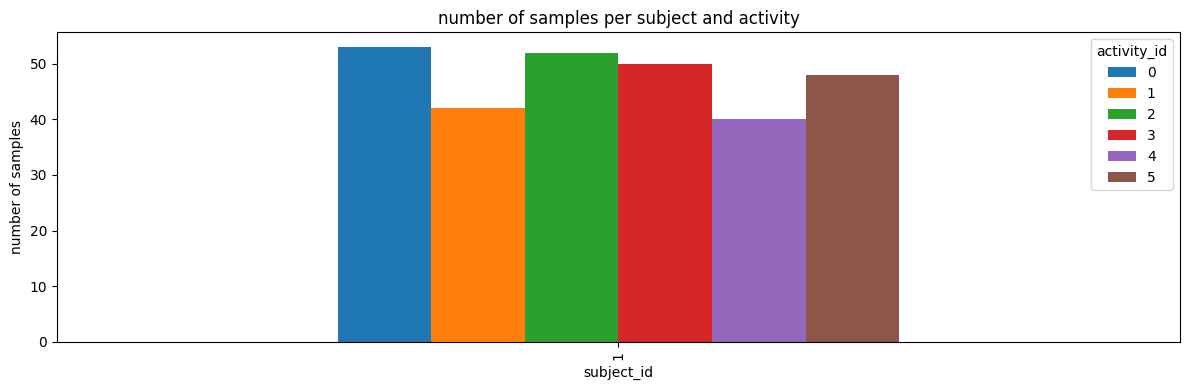

In [5]:
print(f"num_samples: {len(sampler.train_indices)}")

shape = sampler.get_shape()
num_channels = shape[1]
print(f"shape: {shape}")

num_classes = sampler.get_num_classes(sampler.train_indices)
print(f"num_classes: {num_classes}")

sampler.sampler.plot_indices_statistics(sampler.train_indices)

In [9]:
latent_shape = [24, 4, 4]

ae = SpectrogramAEC(latent_c=latent_shape[0]).to(device)
ae.load_state_dict(torch.load(f"models/aec_{latent_shape[0]}_8.pt"))

path = GaussianConditionalProbabilityPath(
    p_data=sampler,
    p_simple_shape=latent_shape,
    alpha=LinearAlpha(),
    beta=LinearBeta(),
).to(device)

vf = FlowTransformerBackbone(latent_channels=latent_shape[0], num_classes=num_classes)
vf.load_state_dict(torch.load(f"models/transformer_{latent_shape[0]}_1.pt"))
# vf = FiLMNetMultiBlock(in_channels=latent_shape[0], y_classes=num_classes).to(device)
# vf.load_state_dict(torch.load(f"models/cnn_{latent_shape[0]}_1.pt"))

<All keys matched successfully>

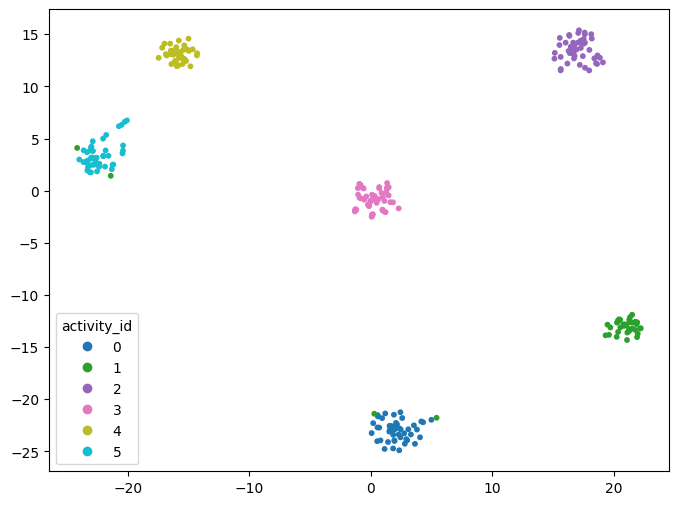

In [14]:
from sklearn.manifold import TSNE

x, y = sampler.sample_train(285)
assert y is not None
x = ae.encode(x).detach()
x = x.view(x.shape[0], -1)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(x)  # type: ignore

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="tab10", s=10)
plt.legend(*scatter.legend_elements(), title="activity_id")
plt.show()

100%|██████████| 99/99 [00:16<00:00,  6.09it/s]


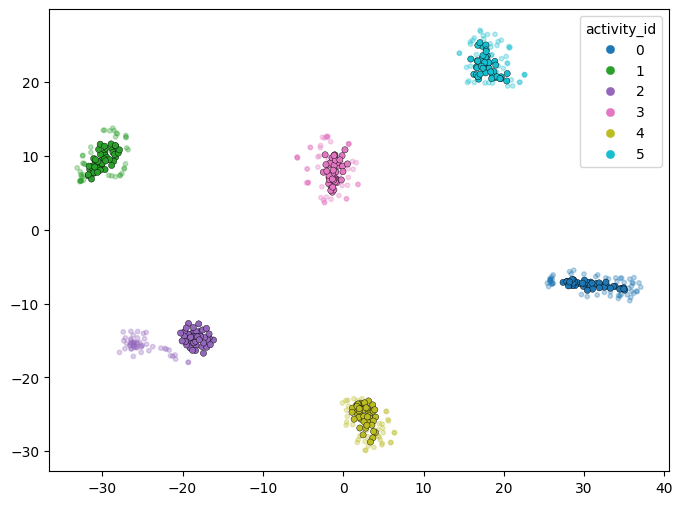

In [7]:
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# -------- Real data --------
x_real, y_real = sampler.sample_train(285)
assert y_real is not None
x_real_latent = ae.encode(x_real, y_real).detach()
x_real_latent = x_real_latent.view(x_real_latent.shape[0], -1)

# -------- Synthetic data --------
num_classes = len(torch.unique(y_real))  # assumes sampler covers all classes
samples_per_class = 285 // num_classes

y_syn = torch.arange(num_classes).repeat_interleave(samples_per_class).to(device)
num_samples = y_syn.shape[0]
num_timesteps = 100
w = 1

# initial noise
x0, _ = path.p_simple.sample(num_samples)
x0 = x0.to(device)

# ODE guidance
ode = CFGVectorFieldODE(vf, guidance_scale=w, null_class=num_classes)
simulator = RK4Simulator(ode)

ts = (
    torch.linspace(0, 1, num_timesteps)
    .view(1, -1, 1, 1, 1)
    .expand(num_samples, -1, 1, 1, 1)
    .to(device)
)

x1 = simulator.simulate(x0, ts, y_syn)
x1_decoded = ae.decode(x1)

# encode synthetic samples into latent
x_syn_latent = ae.encode(x1_decoded, y_syn).detach()
x_syn_latent = x_syn_latent.view(x_syn_latent.shape[0], -1)

# -------- Combine + t-SNE --------
X_all = torch.cat([x_real_latent, x_syn_latent], dim=0).cpu().numpy()
y_all = torch.cat([y_real, y_syn.cpu()], dim=0).numpy()
labels_type = np.array([0] * len(y_real) + [1] * len(y_syn))  # 0=real, 1=synthetic

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_all)

# -------- Plot --------
plt.figure(figsize=(8, 6))

# real samples (translucent)
mask_real = labels_type == 0
plt.scatter(
    X_tsne[mask_real, 0],
    X_tsne[mask_real, 1],
    c=y_all[mask_real],
    cmap="tab10",
    s=10,
    alpha=0.3,  # translucent
    label="Real",
)

# synthetic samples (opaque)
mask_syn = labels_type == 1
scatter = plt.scatter(
    X_tsne[mask_syn, 0],
    X_tsne[mask_syn, 1],
    c=y_all[mask_syn],
    cmap="tab10",
    s=20,
    alpha=1.0,  # solid
    edgecolor="k",
    linewidth=0.3,
    label="Synthetic",
)

plt.legend(*scatter.legend_elements(), title="activity_id")
plt.show()